In [119]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from openai import OpenAI
from pygments import highlight
from pygments.lexers import JsonLexer
from pygments.formatters import HtmlFormatter
from IPython.display import HTML, Markdown, display
from matplotlib.patches import Patch


MODEL_NAME = "gpt-4.1-mini"

In [120]:
# create OpenAI client
load_dotenv(override=True)
api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=api_key)

In [121]:
# function to generate analysis using the OpenAI API
def generate_analysis(prompt):
    """Generates analysis based on the provided prompt using the OpenAI API."""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a senior programme delivery consultant "
                    "specialising in software delivery risk."
                )
            },
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response

# helper function to display results in a readable format
def pretty(obj):
    """Formats and displays the given object in a readable way."""

    if isinstance(obj, str):

        print(obj)

    else:

        formatted_json = json.dumps(
            obj,
            indent=2
        )

        formatter = HtmlFormatter(
            style="monokai"
        )

        html = (
            "<style>"
            + formatter.get_style_defs(".highlight")
            + "</style>"
            + highlight(
                formatted_json,
                JsonLexer(),
                formatter
            )
        )

        display(HTML(html))

In [122]:
# read in dataset
df = pd.read_csv('../data/project_data.csv')
df.head(20)

,Project,Status,Budget,ActualCost,DelayDays,RiskLevel
0,Apollo,Complete,100000,120000,15,High
1,Mercury,In Progress,80000,75000,2,Low
2,Gemini,Delayed,150000,180000,30,High
3,Orion,Complete,50000,45000,0,Low
4,Phoenix,In Progress,120000,140000,10,Medium
5,Atlas,Delayed,95000,110000,20,High
6,Nova,Complete,70000,68000,1,Low
7,Titan,In Progress,200000,230000,25,High
8,Helios,Delayed,130000,145000,18,Medium
9,Vega,Complete,60000,59000,0,Low


In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Project     10 non-null     str  
 1   Status      10 non-null     str  
 2   Budget      10 non-null     int64
 3   ActualCost  10 non-null     int64
 4   DelayDays   10 non-null     int64
 5   RiskLevel   10 non-null     str  
dtypes: int64(3), str(3)
memory usage: 612.0 bytes


In [124]:
df.describe()

,Budget,ActualCost,DelayDays
count,10.000000,10.000000,10.000000
mean,105500.000000,117200.000000,12.100000
std,45853.026072,58520.271891,11.130039
min,50000.000000,45000.000000,0.000000
25%,72500.000000,69750.000000,1.250000
50%,97500.000000,115000.000000,12.500000
75%,127500.000000,143750.000000,19.500000
max,200000.000000,230000.000000,30.000000


In [ ]:
# create metrics
df['CostVariance'] = df['ActualCost'] - df['Budget']
df['CostVariancePct'] = (df['CostVariance'] / df['Budget']) * 100

average_delay = df['DelayDays'].mean()
average_cost_variance_pct = df['CostVariancePct'].mean()
correlation = df["DelayDays"].corr(df["CostVariancePct"])
variance_by_risk = df.groupby("RiskLevel")["CostVariancePct"].mean()


# identify projects considered "at risk" based on:
# - High risk classification
# - Significant delays
# - Significant cost overruns
at_risk_df = df[
    (df["RiskLevel"] == "High")
    | (df["DelayDays"] > 10)
    | (df["CostVariancePct"] > 10)
]

at_risk_count = len(at_risk_df)
at_risk_records = at_risk_df.to_dict(orient="records")

print(at_risk_count)

6


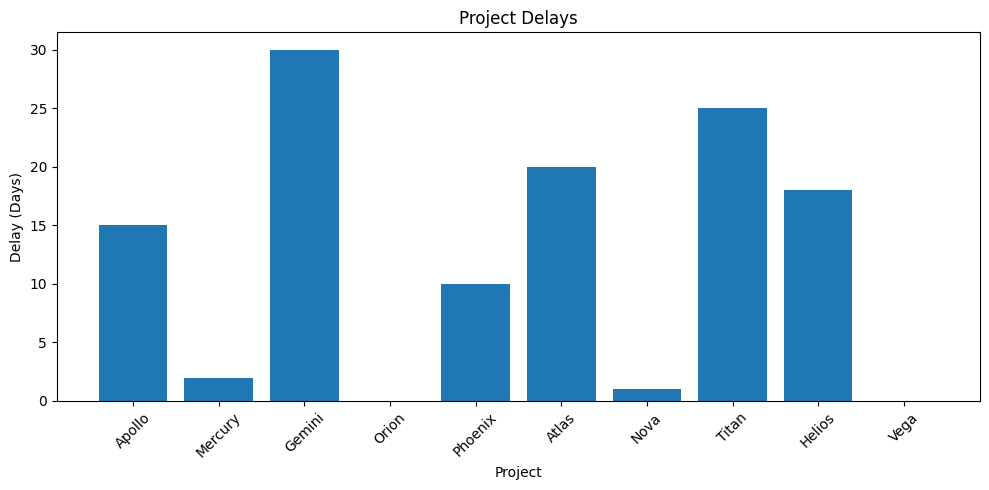

In [126]:
# create project delays bar chart   
plt.figure(figsize=(10,5))
plt.bar(df["Project"], df["DelayDays"])
plt.xticks(rotation=45)
plt.title("Project Delays")
plt.xlabel("Project")
plt.ylabel("Delay (Days)")
plt.tight_layout()
plt.show()

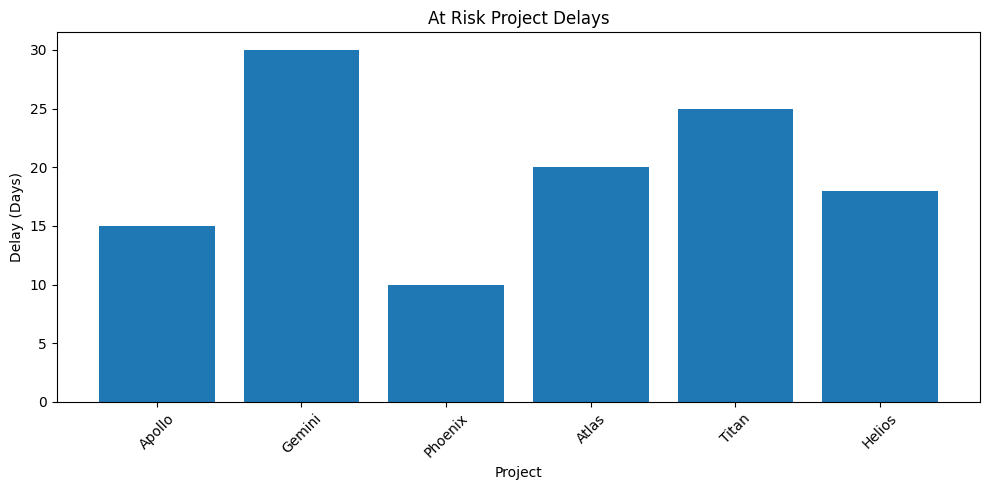

In [133]:
# crreate high-risk project delays bar chart
plt.figure(figsize=(10,5))
plt.bar(at_risk_df["Project"], at_risk_df["DelayDays"])
plt.xticks(rotation=45)
plt.title("At Risk Project Delays")
plt.xlabel("Project")
plt.ylabel("Delay (Days)")
plt.tight_layout()
plt.show()

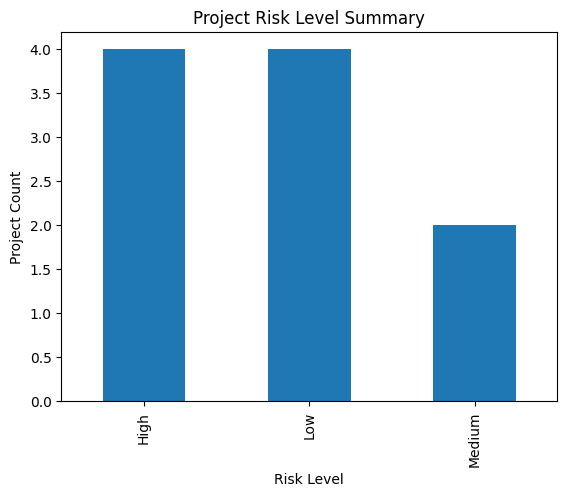

In [128]:
# create project risk level distribution bar chart
risk_counts = df["RiskLevel"].value_counts()
risk_counts.plot(kind="bar")

plt.title("Project Risk Level Summary")
plt.xlabel("Risk Level")
plt.ylabel("Project Count")

plt.show()

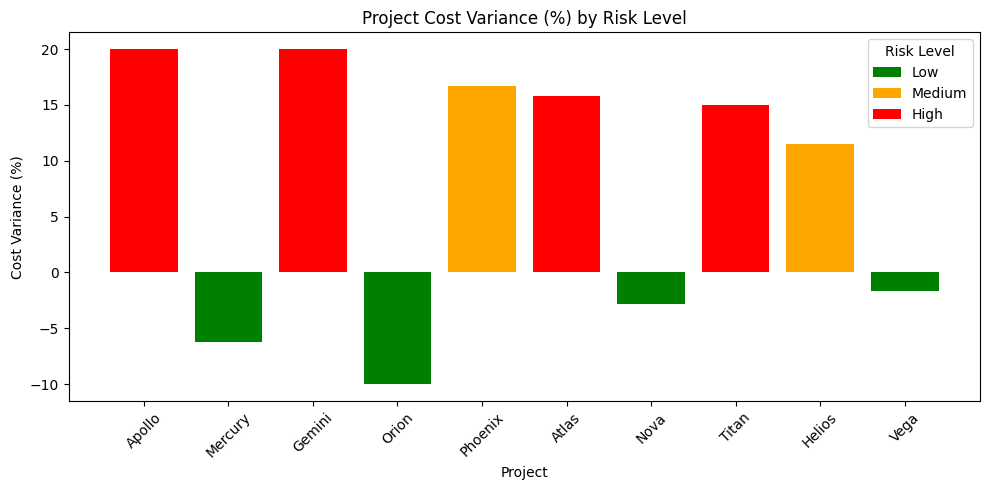

In [129]:
risk_colors = {
    "Low": "green",
    "Medium": "orange",
    "High": "red"
}

colors = [
    risk_colors[risk]
    for risk in df["RiskLevel"]
]

plt.figure(figsize=(10, 5))

plt.bar(
    df["Project"],
    df["CostVariancePct"],
    color=colors
)

legend_elements = [
    Patch(facecolor="green", label="Low"),
    Patch(facecolor="orange", label="Medium"),
    Patch(facecolor="red", label="High")
]

plt.legend(
    handles=legend_elements,
    title="Risk Level"
)

plt.xticks(rotation=45)

plt.title("Project Cost Variance (%) by Risk Level")
plt.xlabel("Project")
plt.ylabel("Cost Variance (%)")

plt.tight_layout()

plt.show()

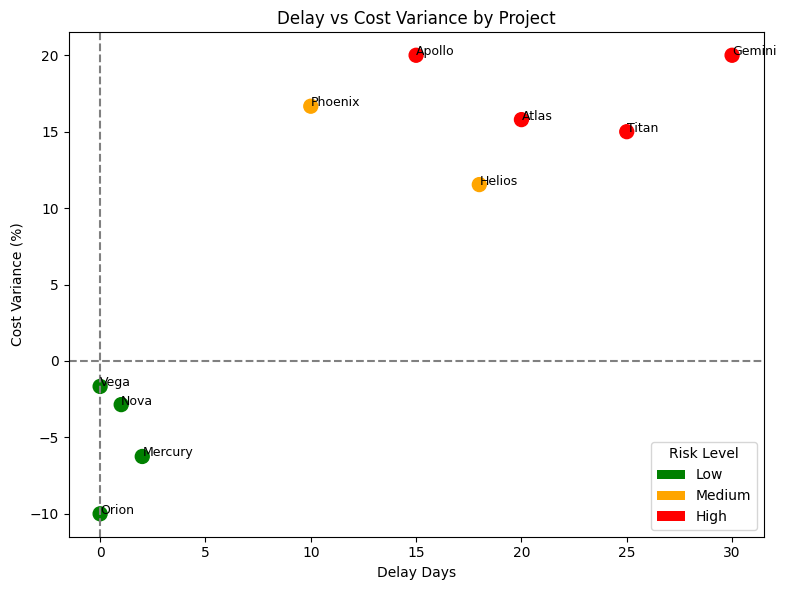

In [130]:
risk_colors = {
    "Low": "green",
    "Medium": "orange",
    "High": "red"
}

colors = [
    risk_colors[risk]
    for risk in df["RiskLevel"]
]

plt.figure(figsize=(8, 6))

plt.scatter(
    df["DelayDays"],
    df["CostVariancePct"],
    c=colors,
    s=100
)

for i, project in enumerate(df["Project"]):

    plt.text(
        df["DelayDays"][i],
        df["CostVariancePct"][i],
        project,
        fontsize=9
    )

legend_elements = [
    Patch(facecolor="green", label="Low"),
    Patch(facecolor="orange", label="Medium"),
    Patch(facecolor="red", label="High")
]

plt.legend(
    handles=legend_elements,
    title="Risk Level"
)

plt.title("Delay vs Cost Variance by Project")

plt.xlabel("Delay Days")

plt.ylabel("Cost Variance (%)")

plt.axhline(
    0,
    color="grey",
    linestyle="--"
)

plt.axvline(
    0,
    color="grey",
    linestyle="--"
)

plt.tight_layout()

plt.show()

In [134]:
analysis_prompt = f"""
You are a senior programme delivery consultant.

Portfolio metrics:

- High-risk projects: {at_risk_count}
- Average delay: {average_delay:.1f} days
- Average cost variance: {average_cost_variance_pct:.1f}%
- Delay/cost variance correlation: {correlation:.2f}

Projects are considered "at risk" if they meet ANY of the following criteria:
- RiskLevel = High
- DelayDays > 10
- CostVariancePct > 10

At risk project records:

{json.dumps(at_risk_records, indent=2)}

Return your response in markdown with these sections:

## Executive Summary

## Observations
Clearly distinguish observed facts from inferred risks.

## Key Risks
Include reasonable interpretations, but clearly distinguish them from observed facts.

## Recommended Actions
Provide practical delivery management actions.

Keep the tone concise and professional.
Only reference issues directly supported by the dataset.

"""

In [135]:
response = generate_analysis(analysis_prompt)
response_content = response.choices[0].message.content
display(Markdown(response_content))

## Executive Summary

The portfolio currently includes six high-risk projects, with an average delay of 12.1 days and an average cost variance of 7.8%. There is a strong positive correlation (0.86) between delays and cost overruns across the portfolio. Six projects meet the "at risk" criteria of high risk, delay over 10 days, or cost variance above 10%, reflecting significant delivery challenges.

## Observations

- Of the six at risk projects, four are classified as High Risk (Apollo, Gemini, Atlas, Titan) and two as Medium Risk (Phoenix, Helios).
- All affected projects have delays exceeding 10 days except Phoenix, which is exactly 10 days delayed but has a cost variance above 10%.
- Cost variances are materially above the 10% threshold for all at-risk projects, ranging from 11.5% (Helios) to 20% (Apollo, Gemini).
- Status distribution among these projects is mixed: two completed, two delayed, and two in progress.
- The strong delay/cost variance correlation (0.86) indicates that schedule slippage is closely linked with cost overruns in this portfolio.

## Key Risks

- Persistent delays of more than 10 days increase likelihood of further cost escalations and stakeholder dissatisfaction.
- High-risk projects show both schedule and cost performance issues, increasing the chance of delivery failure or compromised scope.
- Projects in progress with medium risk but significant delays and cost variances (Phoenix, Helios) may escalate to high risk without intervention.
- Completed delayed projects (Apollo) exhibiting high cost overruns suggest insufficient risk mitigation or corrective actions during execution, potentially impacting overall portfolio outcomes.

## Recommended Actions

- Implement focused recovery plans for high-risk delayed projects (Gemini, Atlas, Titan) prioritizing critical path activities to contain further slippage.
- Conduct root cause analysis on completed projects with cost overruns to improve forecasting and risk mitigation on future deliveries.
- Increase monitoring and engagement with medium risk projects (Phoenix, Helios) showing early warning signs of schedule and cost issues to prevent escalation.
- Leverage the high correlation between delay and cost variance to proactively identify projects trending towards "at risk" status by tracking both metrics continuously.
- Regularly update portfolio risk assessments to reflect actual status and re-baseline budgets and schedules based on latest data where appropriate.